<a href="https://colab.research.google.com/github/Abiliger/Intelligent-analysis-and-data-visualization/blob/main/feature_selection_and_knn_classification/lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, f_classif
from mlxtend.plotting import plot_decision_regions
from google.colab import files

NumPy and Pandas are used for data manipulation and analysis.

Matplotlib and Seaborn are used for creating visualizations to explore and present the data.

Scikit-learn (sklearn) provides essential machine learning tools:

*   load_wine() – loads the Wine dataset used for classification tasks.
*   train_test_split – divides data into training and testing sets.
*   StandardScaler – normalizes data for better model performance.
*   KNeighborsClassifier – implements the K-Nearest Neighbors algorithm.
*   accuracy_score, confusion_matrix, and classification_report – evaluate model performance.
*   SelectKBest and f_classif – select the most important features for the model.

mlxtend helps visualize decision boundaries for classification.

google.colab.files is used to upload or download files in Google Colab.

This block sets up the environment for further data preprocessing, training, and evaluation of the classification model.

In [2]:
wine = load_wine()

This line loads the Wine dataset directly from Scikit-learn’s built-in datasets.
It contains data on 178 wine samples from three different cultivars in Italy, each described by 13 chemical features (such as alcohol content, color intensity, flavanoids, etc.).

In [3]:
X = wine.data[:, :2]
y = wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)


knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In this section, I prepare the dataset and train the K-Nearest Neighbors (KNN) model.

X = wine.data[:, :2] – selects the first two features from the dataset to simplify visualization of decision boundaries.

y = wine.target – stores the class labels (wine types) as the target variable.

train_test_split() – divides the data into:

*   70% for training (X_train, y_train)
*   30% for testing (X_test, y_test)
*   The random_state=42 ensures reproducibility of results.

Then, a KNN classifier is created with n_neighbors=3, meaning each prediction is based on the three closest samples in the feature space.
Finally, knn.fit(X_train, y_train) trains the model using the training data, allowing it to learn the relationship between wine features and their corresponding classes.

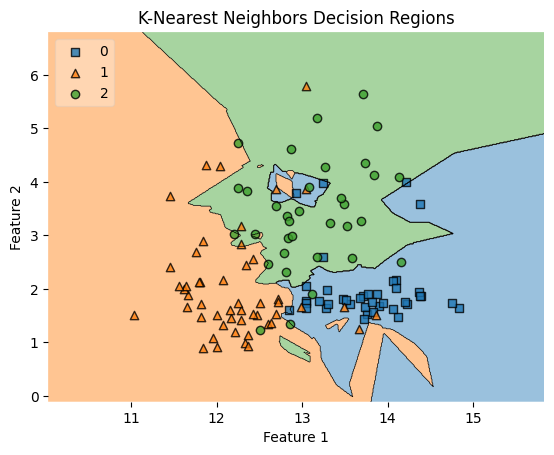

In [4]:
plot_decision_regions(X_train, y_train, clf=knn, legend=2)
plt.title('K-Nearest Neighbors Decision Regions')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

This block visualizes how the K-Nearest Neighbors (KNN) algorithm separates different wine classes based on the two selected features.

plot_decision_regions() – from the mlxtend library, plots the decision surface learned by the trained KNN model.

The background colors represent the regions where the classifier predicts each wine class.

The training samples are shown as points, colored according to their actual class labels.

The legend (legend=2) helps distinguish between the three wine types.

Titles and axis labels are added for clarity, and plt.show() displays the final visualization.

This plot provides an intuitive way to see how well the model distinguishes between classes and how the decision boundaries look in the feature space.

In [5]:
accuracy = knn.score(X_test, y_test)
print('The accuracy is: {0:0.3f}'. format(accuracy))

The accuracy is: 0.815


This code evaluates how accurately the trained KNN classifier predicts the wine classes on the test dataset.

knn.score(X_test, y_test) automatically computes the accuracy, which is the proportion of correctly classified samples.

The result is stored in the variable accuracy.

The print() statement displays the accuracy value formatted to three decimal places.

This step helps measure the overall performance of the model — a higher accuracy means the classifier successfully identifies most wine types based on their chemical features.

In [6]:
url = "https://raw.githubusercontent.com/Abiliger/Intelligent-analysis-and-data-visualization/main/Healthcare-Diabetes.csv"
df_healthcare = pd.read_csv(url)
df_healthcare.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


In this step, I load a healthcare dataset (related to diabetes) directly from a public GitHub repository.

url – contains the link to the raw CSV file hosted on GitHub.

pd.read_csv(url) – uses Pandas to read the CSV file and create a DataFrame named df_healthcare.

df_healthcare.head() – displays the first five rows of the dataset to verify that the data was loaded correctly.

This dataset includes medical measurements and patient information, which can later be analyzed to explore patterns or build predictive models for diabetes detection.

In [7]:
X = df_healthcare.iloc[:, 1:3]  # we take 2 columns, skipping the first one
y = df_healthcare["Outcome"]
feature_names = X.columns

In this section, I define the input features (X) and the target variable (y) for the diabetes prediction task.

X = df_healthcare.iloc[:, 1:3] – selects two specific columns (the 2nd and 3rd) from the dataset to use as features, skipping the first column (which might be an ID or non-numeric label).

y = df_healthcare["Outcome"] – extracts the target variable, which indicates whether a patient is diagnosed with diabetes (1) or not (0).

feature_names = X.columns – stores the names of the selected features for later use in plots or model interpretation.

This step prepares the data for further preprocessing, visualization, and model training, focusing on only two features for better clarity when plotting decision boundaries.

In [8]:
selector = SelectKBest(score_func=f_classif, k=2)
X_new = selector.fit_transform(X, y)
selected_features = [feature_names[i] for i in
selector.get_support(indices=True)]
print(f"Selected features: {selected_features}")

Selected features: ['Pregnancies', 'Glucose']


This section performs feature selection to identify the most relevant features for predicting diabetes outcomes.

SelectKBest(score_func=f_classif, k=2) – initializes a feature selector that uses the ANOVA F-test (f_classif) to evaluate the relationship between each feature and the target variable.

k=2 means that the two best features with the highest statistical scores will be selected.

selector.fit_transform(X, y) – fits the selector to the data and transforms X to include only the selected features.

selector.get_support(indices=True) – returns the indices of the chosen features.

The selected_features list stores the names of the selected features, which are printed for verification.

This process helps reduce dimensionality, remove irrelevant variables, and improve the model’s ability to generalize.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.3,
random_state=42, stratify=y)

In this step, I split the selected feature set into training and testing subsets to evaluate model performance objectively.

X_new – contains only the two best features selected in the previous step.

y – is the target variable representing diabetes outcomes (0 or 1).

test_size=0.3 – reserves 30% of the data for testing and 70% for training the model.

random_state=42 – ensures reproducibility (the same split occurs each time the code is run).

stratify=y – keeps the class distribution balanced between training and testing datasets, preventing bias if one class (e.g., diabetic or non-diabetic) has fewer samples.

This step ensures that the model is trained on one subset of data and evaluated on unseen data, providing a realistic measure of its predictive ability.

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In this step, I apply feature scaling to standardize the input data, ensuring that all selected features contribute equally to the model.

StandardScaler() – from scikit-learn, standardizes features by removing the mean and scaling to unit variance.

scaler.fit_transform(X_train) – calculates the scaling parameters (mean and standard deviation) based on the training data and applies the transformation.

scaler.transform(X_test) – applies the same scaling parameters to the test data (without refitting), keeping the data consistent.

Feature scaling is essential for algorithms like K-Nearest Neighbors (KNN), which rely on distance calculations. Without scaling, features with larger numeric ranges could dominate the distance metric and distort the results.

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In this section, I train the K-Nearest Neighbors (KNN) classifier on the scaled healthcare dataset and use it to make predictions.

KNeighborsClassifier(n_neighbors=5) – creates a KNN model where each prediction is based on the five nearest neighbors in the feature space.

knn.fit(X_train, y_train) – trains (fits) the classifier using the training data. The algorithm stores the feature patterns and class labels to use during prediction.

knn.predict(X_test) – predicts the diabetes outcome (0 = no diabetes, 1 = diabetes) for the unseen test dataset.

This step allows the model to learn patterns in patient data and predict health outcomes for new cases based on similarity to known examples.

Accuracy: 0.78


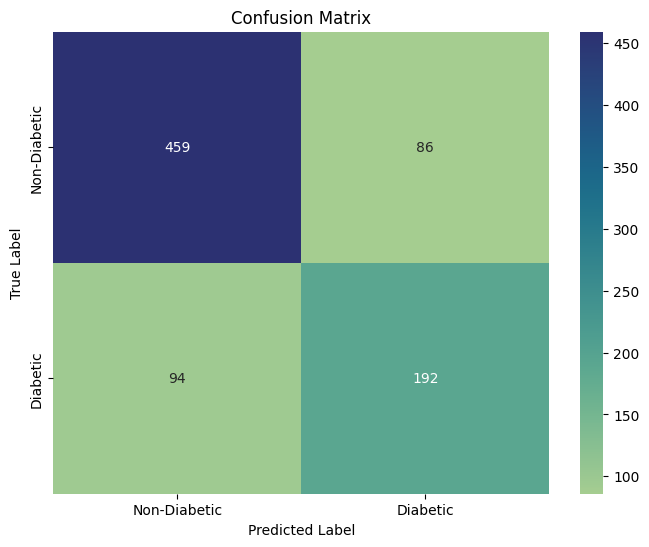

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


target_names = ['Non-Diabetic', 'Diabetic']
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='crest', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

This section evaluates the performance of the trained K-Nearest Neighbors (KNN) model on the healthcare dataset and visualizes its classification results.

accuracy_score(y_test, y_pred) – calculates the model’s accuracy, showing the percentage of correct predictions.

The print() statement displays the accuracy rounded to two decimal places for readability.

confusion_matrix(y_test, y_pred) – computes a confusion matrix, which breaks down the predictions into True Positives, True Negatives, False Positives, and False Negatives.

sns.heatmap() – visualizes this matrix as a colored grid, making it easier to interpret the model’s performance.

*   The x-axis shows predicted labels
*   The x-axis shows predicted labels
*   The y-axis shows true labels

The color intensity helps quickly identify where the model performs well or struggles.

Titles and axis labels make the chart self-explanatory.

In [13]:
class_report = classification_report(y_test, y_pred, target_names = target_names)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.83      0.84      0.84       545
    Diabetic       0.69      0.67      0.68       286

    accuracy                           0.78       831
   macro avg       0.76      0.76      0.76       831
weighted avg       0.78      0.78      0.78       831



This block generates a detailed classification report that evaluates the model’s performance for each class (Diabetic / Non-Diabetic) across multiple metrics.

classification_report(y_test, y_pred, target_names=target_names) – from scikit-learn, computes key metrics for each class:

*   Precision – how many of the model’s positive predictions were actually correct.
*   Recall – how many actual positive cases the model successfully identified.
*   F1-score – the harmonic mean of precision and recall, giving a balanced measure of accuracy.
*   Support – the number of true instances for each class in the test set.

The report provides a comprehensive view of model quality, showing strengths and weaknesses beyond overall accuracy

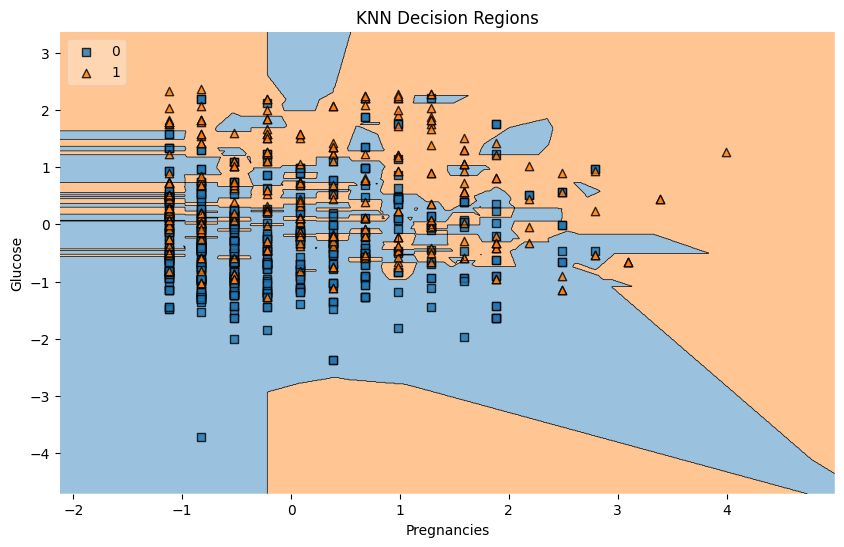

In [14]:
plt.figure(figsize=(10, 6))
plot_decision_regions(X_test, y_test.values, clf=knn, legend=2)
plt.title('KNN Decision Regions')
plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.show()

This block visualizes how the trained K-Nearest Neighbors (KNN) model classifies patients in the test dataset based on the two selected features.

plot_decision_regions() – draws the decision boundaries that the KNN classifier has learned, showing how the model divides the feature space into regions belonging to different classes.

Each colored region corresponds to a predicted class (e.g., Diabetic or Non-Diabetic).

The points represent actual test samples, colored according to their true class labels.

The legend=2 option displays class names for easier interpretation.

Axis labels are dynamically assigned from selected_features to indicate which features are used in classification.

This visualization provides an intuitive understanding of how the model differentiates between classes and reveals how well the decision boundaries align with the real data.